In [33]:
from experiments.datasets import datasets
from vertex_voyage.temporal import to_nx_graph
import networkx as nx
from vertex_voyage.cli import _enumerated_event_stream
from vertex_voyage.cli import VertexEnumerator

t = VertexEnumerator()
dataset = to_nx_graph(_enumerated_event_stream("CITESEER", t))
dataset

In [21]:
dataset.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

In [34]:
from vertex_voyage.cli import VertexEnumerator
from vertex_voyage.node2vec import Node2Vec
from experiments.datasets import dataset_params
from vertex_voyage.temporal import buffered
import random 
import numpy as np

def _sort_temporal_events(og_events, track_seen: bool):
    events = og_events.copy()
    if track_seen:
        random.shuffle(events)
    nodes = set()
    seen = set()
    sorted_events = []
    while(len(events) > 0):
        if track_seen:
            event = None
            for e in events:
                if e.src in seen or e.dest in seen:
                    event = e
                    break
            if event is None:
                event = events[0]
            events.remove(event)
            seen.add(event.src)
            seen.add(event.dest)
        else:
            event = events.pop(0)
        nodes.add(event.src)
        nodes.add(event.dest)
        sorted_events.append(event)
    return sorted_events

def _process_temporal_buffers(sorted_events, buffer_size: int, partitioner, models, original_graph):
    total_edges = 0
    nodes = set()
    iteration_precisions, iteration_recalls, iteration_f1s = [], [], []
    total_buffers = (len(sorted_events) + buffer_size - 1) // buffer_size
    processed_after_last_f1 = 0
    old_f1_score = 0
    result = [] 

    for bi, buffer in enumerate(buffered(sorted_events, buffer_size)):
        processed_after_last_f1 += len(buffer)
        for event in buffer:
            nodes.add(event.src)
            nodes.add(event.dest)
        partitioner.push(buffer)
        curr_result = []
        total_edges += len(buffer)
        # for part, partition_buffer in partitioner.get_partition_buffers(buffer):
        #     models[part].update(partition_buffer)
        

    #     embeddings = partitioner.get_distributed_embedding(models, nodes)
    # return 

t = VertexEnumerator()
embedding_model = Node2Vec(**dataset_params["CITESEER"])
embedding_model.fit(dataset)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


array([[ 0.36156043,  0.65872824, -0.32746974, ..., -0.32935819,
         0.63328373, -0.01938479],
       [ 0.33669877,  0.5590499 , -0.07168039, ..., -0.23566198,
         0.31837773, -0.10577047],
       [ 0.26901299,  0.33877814,  0.11121532, ..., -0.59390301,
         0.5556438 ,  0.50318104],
       ...,
       [-0.06617496, -0.29686522,  0.38687366, ..., -1.48010397,
        -0.14301011,  0.31281641],
       [-1.01788604, -0.36404005,  0.05884853, ..., -0.38843289,
        -0.3073318 , -0.63589942],
       [-1.03152788, -0.33170471,  0.04883812, ..., -0.39742866,
        -0.34913597, -0.60409594]])

In [35]:
# for every node, calculate closest node by embedding 
closest_nodes = {}
for node in dataset.nodes:
    node_embedding = embedding_model.embed_node(node)
    closest_node = None
    closest_distance = float('inf')
    for other_node in dataset.nodes:
        if other_node == node:
            continue
        other_embedding = embedding_model.embed_node(other_node)
        distance = np.linalg.norm(node_embedding - other_embedding)
        if distance < closest_distance:
            closest_distance = distance
            closest_node = other_node
    closest_nodes[node] = closest_node
display(closest_nodes)

{0: 1711,
 1: 1665,
 2: 117,
 3: 1484,
 4: 117,
 5: 117,
 6: 1583,
 7: 948,
 8: 161,
 9: 16,
 10: 489,
 11: 9,
 12: 9,
 13: 2837,
 14: 2471,
 15: 9,
 16: 9,
 17: 18,
 18: 19,
 19: 18,
 20: 22,
 21: 20,
 22: 1528,
 23: 1195,
 24: 30,
 25: 23,
 26: 1206,
 27: 1201,
 28: 23,
 29: 1720,
 30: 24,
 31: 33,
 32: 2663,
 33: 400,
 34: 560,
 35: 38,
 36: 1486,
 37: 42,
 38: 39,
 39: 38,
 40: 1633,
 41: 1531,
 42: 1579,
 43: 1743,
 44: 421,
 45: 1435,
 46: 1435,
 47: 45,
 48: 49,
 49: 48,
 50: 56,
 51: 50,
 52: 1421,
 53: 50,
 54: 581,
 55: 160,
 56: 50,
 57: 157,
 58: 158,
 59: 159,
 60: 2940,
 61: 189,
 62: 1346,
 63: 2455,
 64: 2065,
 65: 3017,
 66: 1164,
 67: 3025,
 68: 69,
 69: 68,
 70: 71,
 71: 70,
 72: 74,
 73: 516,
 74: 72,
 75: 76,
 76: 75,
 77: 2455,
 78: 2455,
 79: 81,
 80: 184,
 81: 79,
 82: 83,
 83: 82,
 84: 86,
 85: 2030,
 86: 551,
 87: 36,
 88: 1705,
 89: 90,
 90: 91,
 91: 90,
 92: 89,
 93: 94,
 94: 93,
 95: 98,
 96: 1489,
 97: 2468,
 98: 1282,
 99: 102,
 100: 1281,
 101: 1378,
 10

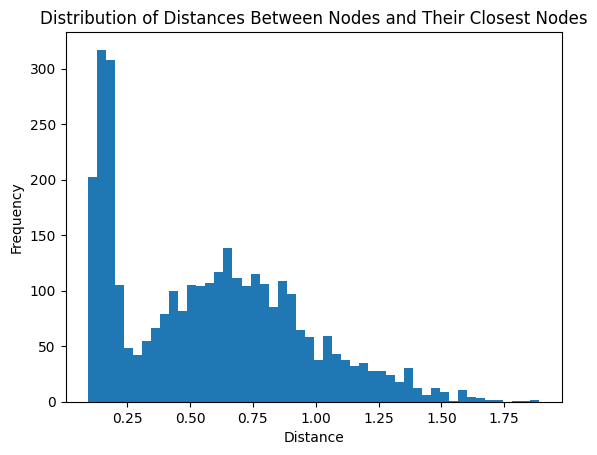

In [36]:
import matplotlib.pyplot as plt

# plot distribution of distances between nodes and their closest nodes
distances = []
for node, closest_node in closest_nodes.items():
    node_embedding = embedding_model.embed_node(node)
    closest_embedding = embedding_model.embed_node(closest_node)
    distance = np.linalg.norm(node_embedding - closest_embedding)
    distances.append(distance)
plt.hist(distances, bins=50)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Distances Between Nodes and Their Closest Nodes")
plt.show()


Buffer size: 1000, Graph nodes: 788, Graph edges: 1000


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Node 2453 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2454 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1271 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1311 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1277 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1555 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1027 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1722 not found in Word2Vec vocabulary. This may indi

{2453: 2454,
 2454: 2453,
 1271: 1276,
 107: 1689,
 1311: 1277,
 106: 1277,
 1277: 1311,
 8: 552,
 1555: 1473,
 1027: 114,
 3: 1484,
 114: 1722,
 1722: 114,
 1473: 1472,
 552: 161,
 1484: 114,
 635: 638,
 637: 638,
 636: 623,
 623: 1505,
 638: 635,
 1505: 623,
 1536: 951,
 1537: 1728,
 418: 1728,
 1493: 1540,
 1728: 418,
 1672: 1540,
 1: 990,
 1193: 1499,
 1564: 990,
 1506: 990,
 1667: 1588,
 1565: 1711,
 1501: 1509,
 1666: 1565,
 1551: 1548,
 1644: 1645,
 1699: 1510,
 1510: 1699,
 1322: 1666,
 582: 938,
 1498: 1194,
 423: 588,
 141: 953,
 522: 1419,
 1704: 953,
 420: 424,
 953: 141,
 1669: 381,
 381: 1669,
 1556: 933,
 933: 1556,
 1499: 1193,
 132: 135,
 139: 1573,
 73: 516,
 388: 1031,
 1031: 388,
 1645: 1644,
 136: 135,
 53: 50,
 1711: 1565,
 1719: 1540,
 1496: 1194,
 1194: 1496,
 1433: 1432,
 1432: 1433,
 1678: 1500,
 1597: 1598,
 541: 1420,
 140: 1419,
 1420: 540,
 1424: 1517,
 1517: 1424,
 540: 1420,
 1683: 1541,
 1541: 1683,
 1598: 1597,
 951: 1536,
 382: 385,
 385: 384,
 387: 3

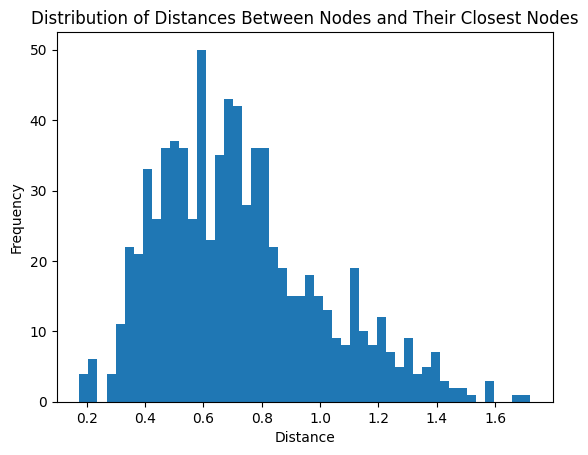

Buffer size: 1000, Graph nodes: 1033, Graph edges: 1000


Node 1485 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1280 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1547 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1306 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2134 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1295 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2145 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1309 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1063 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1695 not found in Word2Vec vocabulary. Th

{36: 1486,
 1485: 1280,
 1280: 1547,
 1547: 1280,
 1306: 1687,
 107: 1306,
 114: 1699,
 140: 1681,
 860: 862,
 862: 860,
 119: 2134,
 2134: 119,
 1295: 222,
 222: 1044,
 2145: 1309,
 1309: 2145,
 858: 603,
 1063: 1062,
 531: 401,
 550: 1694,
 1695: 1693,
 88: 235,
 235: 88,
 624: 865,
 339: 2265,
 327: 340,
 2661: 2123,
 1343: 2123,
 2662: 2661,
 2382: 1065,
 1065: 2382,
 528: 599,
 600: 599,
 253: 1778,
 255: 253,
 1778: 253,
 2481: 560,
 13: 560,
 35: 39,
 40: 1632,
 1488: 45,
 47: 45,
 1660: 0,
 1: 155,
 1419: 112,
 1420: 113,
 228: 230,
 230: 228,
 232: 502,
 502: 231,
 231: 502,
 1106: 1010,
 1044: 222,
 553: 557,
 151: 83,
 523: 32,
 32: 3162,
 2435: 968,
 968: 967,
 1632: 1633,
 577: 557,
 2910: 2912,
 2912: 2910,
 2372: 2373,
 2373: 2372,
 2513: 2514,
 202: 2513,
 14: 2476,
 602: 1930,
 214: 2117,
 215: 214,
 1798: 1801,
 1009: 1801,
 85: 1741,
 568: 558,
 1023: 1024,
 1024: 1023,
 557: 577,
 2483: 1347,
 2535: 2483,
 599: 2675,
 149: 2234,
 2234: 2028,
 406: 1446,
 405: 403,
 

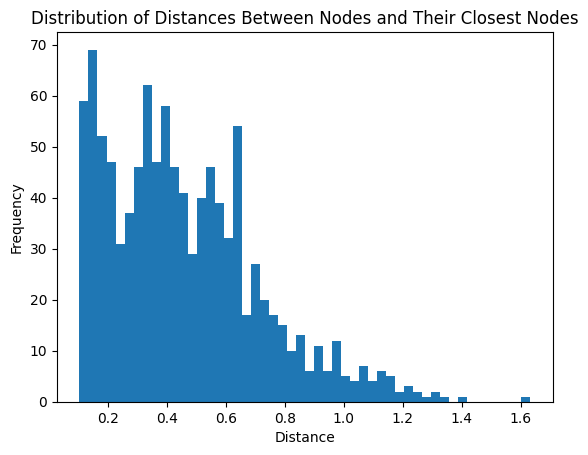

Buffer size: 1000, Graph nodes: 1132, Graph edges: 1000


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Node 1643 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1746 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1642 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1501 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1425 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1249 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1252 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1631 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2031 not found in Word2Vec vocabulary. This may indicate an issue with the rando

{1643: 1642,
 1746: 1642,
 1642: 1746,
 1501: 1686,
 1425: 1686,
 398: 399,
 399: 398,
 393: 55,
 55: 160,
 1249: 1251,
 1252: 1249,
 517: 1631,
 1631: 2031,
 2031: 1631,
 85: 2030,
 1314: 2793,
 71: 70,
 1: 1645,
 2772: 2488,
 2774: 2773,
 2485: 2487,
 2486: 3045,
 2487: 2485,
 2488: 2772,
 3045: 2486,
 533: 595,
 595: 2482,
 1944: 1945,
 1945: 1944,
 870: 2155,
 2160: 2159,
 14: 9,
 563: 2458,
 1101: 1103,
 1103: 1101,
 149: 902,
 32: 2472,
 234: 587,
 587: 583,
 1119: 1122,
 1120: 1121,
 1122: 1121,
 2516: 438,
 438: 2516,
 70: 71,
 397: 254,
 254: 397,
 2433: 2974,
 2974: 2433,
 583: 587,
 738: 1081,
 1464: 740,
 594: 609,
 145: 2483,
 1629: 1675,
 309: 308,
 573: 602,
 602: 573,
 1246: 2228,
 2228: 1245,
 1798: 1802,
 1801: 1800,
 596: 606,
 1068: 1072,
 1072: 1068,
 2172: 2241,
 1442: 2172,
 24: 30,
 30: 24,
 2430: 2431,
 2431: 2430,
 2462: 1337,
 1343: 1337,
 217: 966,
 2373: 2432,
 2480: 401,
 2029: 401,
 1096: 121,
 1318: 1316,
 45: 46,
 46: 45,
 382: 383,
 383: 382,
 608: 868

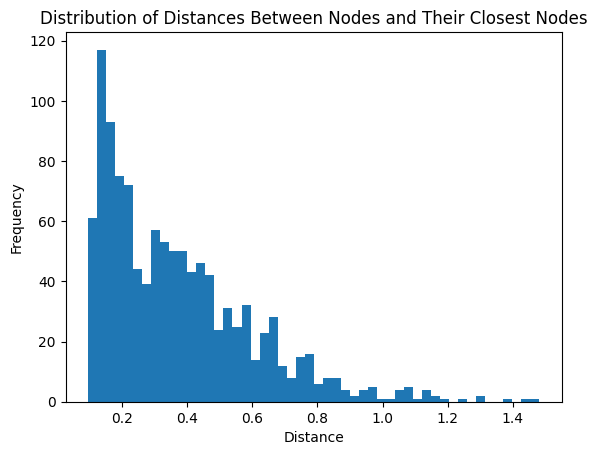

Buffer size: 1000, Graph nodes: 1120, Graph edges: 1000


Node 2051 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1533 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1498 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1385 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2574 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1384 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 1386 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2560 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2558 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2559 not found in Word2Vec vocabulary. Th

{269: 2053,
 2051: 2896,
 52: 614,
 54: 50,
 1533: 1498,
 1498: 1533,
 78: 2574,
 1385: 1386,
 2574: 1384,
 1384: 2574,
 1386: 1384,
 2560: 2558,
 2558: 2559,
 2559: 2558,
 919: 920,
 920: 919,
 90: 906,
 2224: 903,
 2694: 2696,
 2696: 2694,
 1316: 124,
 124: 1316,
 2221: 2459,
 13: 568,
 118: 128,
 128: 121,
 2652: 568,
 656: 768,
 768: 656,
 1540: 1541,
 1541: 1540,
 866: 2231,
 2230: 3144,
 137: 1749,
 1425: 1540,
 2638: 1951,
 1951: 2638,
 2061: 958,
 959: 716,
 594: 596,
 596: 599,
 2956: 2962,
 2957: 2962,
 2962: 2956,
 2213: 2212,
 2212: 2213,
 533: 2029,
 2029: 533,
 560: 570,
 567: 560,
 1518: 858,
 858: 1518,
 2993: 2916,
 2253: 2993,
 1715: 1033,
 1493: 1715,
 604: 863,
 863: 604,
 3034: 3035,
 3035: 3034,
 1632: 1640,
 1558: 1641,
 2053: 2056,
 991: 992,
 936: 991,
 607: 862,
 605: 860,
 632: 1863,
 1863: 632,
 409: 404,
 408: 409,
 194: 2376,
 244: 2376,
 1038: 242,
 1039: 2282,
 536: 2388,
 2388: 536,
 2389: 2388,
 327: 1312,
 1312: 327,
 614: 52,
 575: 152,
 152: 575,
 1

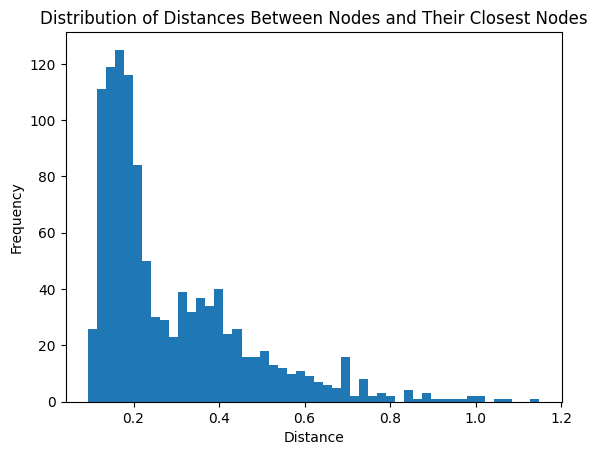

Buffer size: 536, Graph nodes: 819, Graph edges: 536


Node 2855 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2834 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2378 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2379 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2643 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2645 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2644 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 2642 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 3138 not found in Word2Vec vocabulary. This may indicate an issue with the random walks or encoding.
Node 3023 not found in Word2Vec vocabulary. Th

{2855: 2834,
 2834: 2855,
 2378: 2379,
 2379: 2378,
 2643: 2645,
 2645: 2642,
 2644: 2642,
 2642: 2645,
 3138: 3023,
 3023: 2645,
 3083: 362,
 3082: 1244,
 3081: 1243,
 2944: 2945,
 2945: 2944,
 2952: 2953,
 2953: 2952,
 1960: 1959,
 2185: 374,
 1961: 1960,
 2342: 1981,
 1959: 1960,
 2597: 2598,
 2598: 2597,
 3118: 3119,
 3119: 3118,
 302: 303,
 303: 302,
 2408: 2409,
 2409: 2408,
 1894: 1895,
 1895: 1894,
 2328: 2329,
 2329: 2328,
 752: 753,
 753: 752,
 2034: 754,
 754: 2034,
 2163: 2720,
 2165: 2166,
 2166: 2164,
 2164: 2166,
 2869: 2870,
 2870: 2869,
 1158: 1159,
 1159: 1158,
 1284: 1285,
 1285: 1284,
 1264: 1265,
 1265: 1264,
 2332: 2214,
 2215: 2214,
 2214: 2332,
 2717: 2718,
 2718: 2717,
 3008: 3009,
 3009: 3008,
 2946: 2947,
 2947: 2946,
 2167: 2414,
 2168: 2414,
 2414: 2167,
 2238: 3130,
 2239: 2238,
 2741: 2238,
 3140: 2238,
 2742: 3140,
 3130: 2238,
 2330: 2331,
 2331: 2330,
 329: 343,
 330: 343,
 343: 329,
 899: 900,
 900: 899,
 898: 2935,
 2935: 898,
 3191: 3192,
 3192: 319

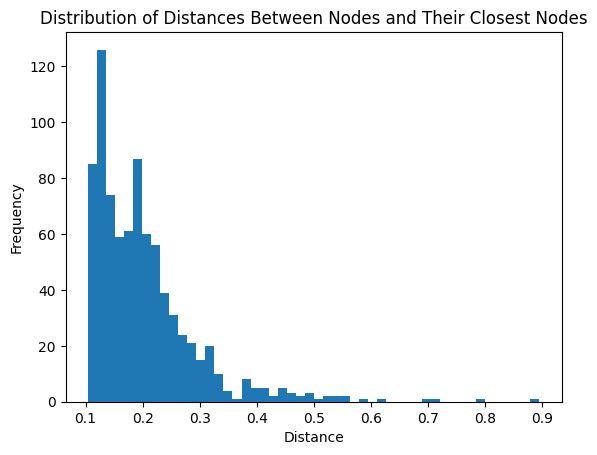

In [38]:
# now lets see if buffered version is the same 
t_temporal = VertexEnumerator()
dataset_temporal = _enumerated_event_stream("CITESEER", t_temporal)
events = list(dataset_temporal)
sorted_events = _sort_temporal_events(events, track_seen=True)
for buffer in buffered(sorted_events, 1000):
    # lets create graph of these events 
    g = to_nx_graph(buffer)
    print(f"Buffer size: {len(buffer)}, Graph nodes: {len(g.nodes)}, Graph edges: {len(g.edges)}")
    em = Node2Vec(**dataset_params["CITESEER"])
    em.fit(g)
    # now calculate closest nodes for this buffer
    distances = []
    closest_nodes_buffer = {}
    for node in g.nodes:
        node_embedding = em.embed_node(node)
        closest_node = None
        closest_distance = float('inf')
        for other_node in g.nodes:
            if other_node == node:
                continue
            other_embedding = em.embed_node(other_node)
            distance = np.linalg.norm(node_embedding - other_embedding)
            if distance < closest_distance:
                closest_distance = distance
                closest_node = other_node
        closest_nodes_buffer[node] = closest_node
        distances.append(closest_distance)
    display(closest_nodes_buffer)
    plt.hist(distances, bins=50)
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.title("Distribution of Distances Between Nodes and Their Closest Nodes")
    plt.show()

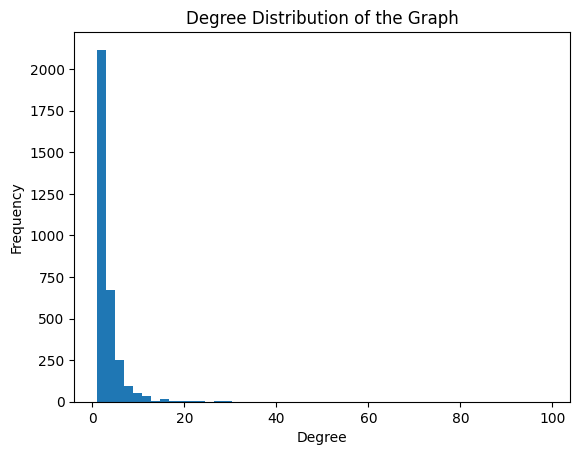

In [39]:
# degree distribution of the graph
degree_sequence = sorted([d for n, d in dataset.degree()], reverse=True)
plt.hist(degree_sequence, bins=50)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of the Graph")
plt.show()


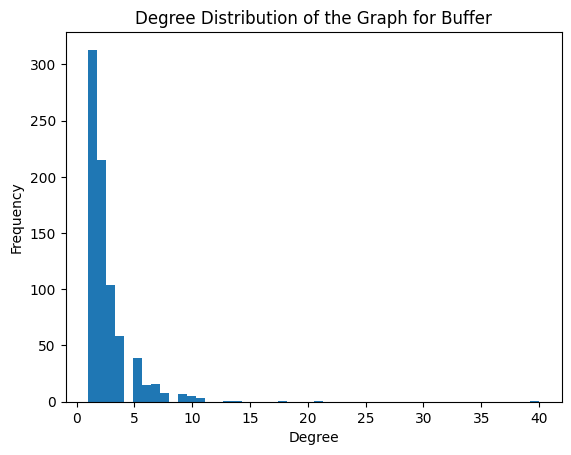

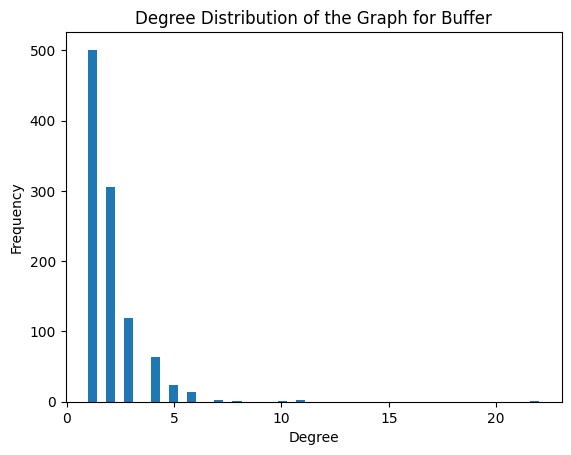

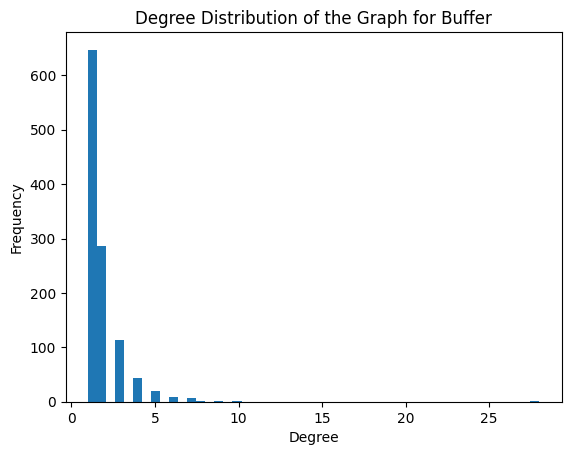

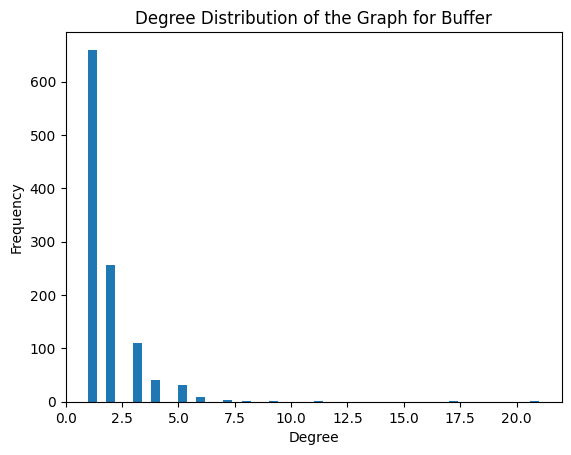

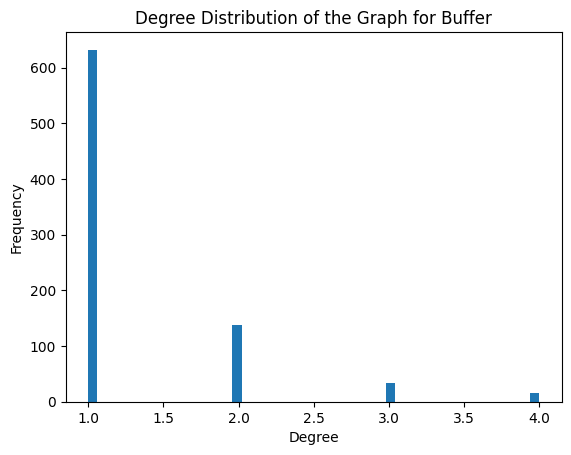

In [40]:
# plot degree distribution for individual buffers
for buffer in buffered(sorted_events, 1000):
    g = to_nx_graph(buffer)
    degree_sequence = sorted([d for n, d in g.degree()], reverse=True)
    plt.hist(degree_sequence, bins=50)
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution of the Graph for Buffer")
    plt.show()